In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q Sastrawi

import os
import re
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
BASE_DIR = '/content/drive/MyDrive/NLP_Final_Project_Final'
DATA_DIR = f'{BASE_DIR}/data/splits'
MODEL_DIR = f'{BASE_DIR}/models/classical'
ARTIFACT_DIR = f'{BASE_DIR}/artifacts/classical'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

df_train = pd.read_csv(f'{DATA_DIR}/train_data.csv')
df_val   = pd.read_csv(f'{DATA_DIR}/val_data.csv')
df_test  = pd.read_csv(f'{DATA_DIR}/test_data.csv')

print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

Train: (7797, 4)
Val  : (975, 4)
Test : (975, 4)


PREPROCESSING

In [ ]:
stop_factory = StopWordRemoverFactory()
stopwords_default = set(stop_factory.get_stop_words())

keep_words = {'tidak', 'bukan', 'belum', 'jangan', 'kurang'}
custom_stopwords = stopwords_default - keep_words

stemmer = StemmerFactory().create_stemmer()

def remove_stopwords_custom(text):
    tokens = str(text).split()
    tokens = [tok for tok in tokens if tok not in custom_stopwords]
    return ' '.join(tokens)

def preprocess_classical(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = remove_stopwords_custom(text)
    text = stemmer.stem(text)
    return text

In [ ]:
df_train['text_classical'] = df_train['text_clean'].apply(preprocess_classical)
df_val['text_classical']   = df_val['text_clean'].apply(preprocess_classical)
df_test['text_classical']  = df_test['text_clean'].apply(preprocess_classical)

df_train[['text_clean', 'text_classical', 'sentimen']].head()

,text_clean,text_classical,sentimen
0,bos garuda: citilink gabung pelita air barenga...,bos garuda citilink gabung pelita air bareng i...,netral
1,pesan airlangga untuk presiden baru: dunia tid...,pesan airlangga presiden baru dunia tidak baik...,netral
2,"minta restu investor, bank mandiri (bmri) mau ...",minta restu investor bank mandiri bmri mau buy...,positif
3,"segini besaran uang pensiun jokowi, sudah mula...",gin besar uang pensiun jokowi mulai cair,netral
4,ini daftar lengkap jajaran direksi dan komisar...,daftar lengkap jajar direksi komisaris bni has...,netral


In [ ]:
# Preview
preview_classical = df_train[['judul', 'text_clean', 'text_classical', 'sentimen']].sample(10, random_state=42).reset_index(drop=True)
display(preview_classical)

,judul,text_clean,text_classical,sentimen
0,"Trump Tunda Perang Dagang, Dolar Turun ke Rp 1...","trump tunda perang dagang, dolar turun ke rupi...",trump tunda perang dagang dolar turun rupiah 1...,positif
1,"Terungkap, Jokowi Ketar-ketir Waktu Dolar AS S...","terungkap, jokowi ketar-ketir waktu dolar as s...",ungkap jokowi ketar tir waktu dolar as sempat ...,negatif
2,Krom Bank Andalkan Modal Dulu Buat Salurkan Kr...,krom bank andalkan modal dulu buat salurkan kr...,krom bank andal modal dulu buat salur kredit,netral
3,"Robert Kiyosaki Ingatkan Nasib Buruk Dolar, Ka...","robert kiyosaki ingatkan nasib buruk dolar, ka...",robert kiyosaki ingat nasib buruk dolar kasih ...,netral
4,"Elon Musk Jadi Musuh Warga AS, Tesla Kena Boik...","elon musk jadi musuh warga as, tesla kena boik...",elon musk jadi musuh warga as tesla kena boiko...,negatif
5,"Bank Mega Syariah Cetak Laba Rp253,19 M Sepanj...","bank mega syariah cetak laba rupiah 253,19 m s...",bank mega syariah cetak laba rupiah 253 19 m p...,positif
6,"Investor Pelototi Tanda-Tanda dari AS, Harga M...","investor pelototi tanda-tanda dari as, harga m...",investor pelotot tanda tanda as harga minyak c...,netral
7,Emiten Suami Puan (CBRE) Targetkan Lonjakan Pe...,emiten suami puan (cbre) targetkan lonjakan pe...,emiten suami puan cbre target lonjak dapat 3 k...,positif
8,"Jensen Huang Lego Besar-Besaran, Saham Nvidia ...","jensen huang lego besar-besaran, saham nvidia ...",jensen huang lego besar besar saham nvidia ambruk,negatif
9,Alasan Danantara Angkat Tokoh Global Jadi Dewa...,alasan danantara angkat tokoh global jadi dewa...,alas danantara angkat tokoh global jadi dewan ...,netral


TF-IDF vectorization

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(df_train['text_classical'])
X_val   = tfidf.transform(df_val['text_classical'])
X_test  = tfidf.transform(df_test['text_classical'])

y_train = df_train['label_id'].values
y_val   = df_val['label_id'].values
y_test  = df_test['label_id'].values

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (7797, 10867)
X_val  : (975, 10867)
X_test : (975, 10867)


In [ ]:
label_names = ['negatif', 'netral', 'positif']

def compute_metrics_full(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro
    }

def plot_confusion_matrix_simple(cm, labels, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, str(cm[i, j]),
                horizontalalignment='center',
                color='white' if cm[i, j] > threshold else 'black'
            )

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

Tuning SVM

In [ ]:
svm_grid = [0.25, 0.5, 1.0, 2.0, 4.0]

best_svm = None
best_svm_c = None
best_svm_f1 = -1

for c in svm_grid:
    model = LinearSVC(C=c, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average='macro')
    print(f"C={c} | Val Macro-F1={val_f1:.4f}")

    if val_f1 > best_svm_f1:
        best_svm_f1 = val_f1
        best_svm = model
        best_svm_c = c

print("Best SVM C:", best_svm_c)
print("Best SVM Val Macro-F1:", best_svm_f1)

C=0.25 | Val Macro-F1=0.8276
C=0.5 | Val Macro-F1=0.8315
C=1.0 | Val Macro-F1=0.8314
C=2.0 | Val Macro-F1=0.8306
C=4.0 | Val Macro-F1=0.8255
Best SVM C: 0.5
Best SVM Val Macro-F1: 0.8315497799846335


Tuning Random Forest

In [ ]:
rf_grid = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2},
    {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5},
]

best_rf = None
best_rf_params = None
best_rf_f1 = -1

for params in rf_grid:
    model = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average='macro')
    print(f"{params} | Val Macro-F1={val_f1:.4f}")

    if val_f1 > best_rf_f1:
        best_rf_f1 = val_f1
        best_rf = model
        best_rf_params = params

print("Best RF Params:", best_rf_params)
print("Best RF Val Macro-F1:", best_rf_f1)

{'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | Val Macro-F1=0.7858
{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2} | Val Macro-F1=0.7898
{'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2} | Val Macro-F1=0.7437
{'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5} | Val Macro-F1=0.7441
Best RF Params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}
Best RF Val Macro-F1: 0.789833859331654


Retrain best model di train dan val

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

df_trainval = pd.concat([df_train, df_val], axis=0).reset_index(drop=True)
df_trainval['text_classical'] = df_trainval['text_clean'].apply(preprocess_classical)

tfidf_final = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

X_trainval   = tfidf_final.fit_transform(df_trainval['text_classical'])
X_test_final = tfidf_final.transform(df_test['text_classical'])

y_trainval = df_trainval['label_id'].values
y_test     = df_test['label_id'].values

base_svm   = LinearSVC(C=best_svm_c, class_weight='balanced', random_state=42)
svm_final  = CalibratedClassifierCV(estimator=base_svm, cv=5, method='sigmoid')
svm_final.fit(X_trainval, y_trainval)

rf_final = RandomForestClassifier(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    min_samples_split=best_rf_params['min_samples_split'],
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_trainval, y_trainval)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

SVM Metrics: {'accuracy': 0.8297435897435897, 'precision_macro': 0.8308164864687081, 'recall_macro': 0.8271297083299806, 'f1_macro': 0.828888537587936}
              precision    recall  f1-score   support

     negatif       0.82      0.79      0.80       256
      netral       0.82      0.84      0.83       430
     positif       0.86      0.85      0.85       289

    accuracy                           0.83       975
   macro avg       0.83      0.83      0.83       975
weighted avg       0.83      0.83      0.83       975



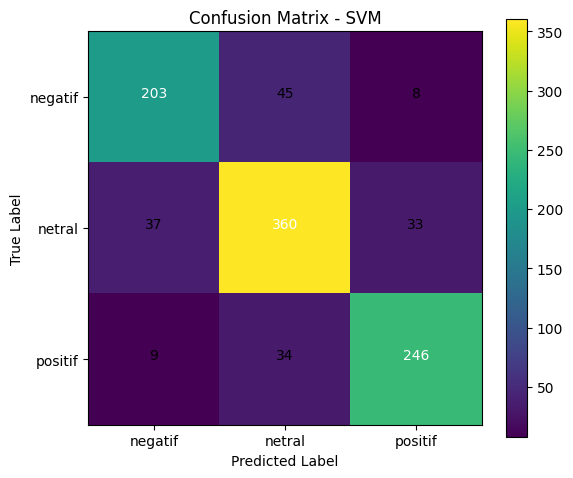

In [ ]:
svm_pred = svm_final.predict(X_test_final)

svm_metrics = compute_metrics_full(y_test, svm_pred)
svm_cm = confusion_matrix(y_test, svm_pred)

print("SVM Metrics:", svm_metrics)
print(classification_report(y_test, svm_pred, target_names=label_names, zero_division=0))
plot_confusion_matrix_simple(svm_cm, label_names, "Confusion Matrix - SVM")

RF Metrics: {'accuracy': 0.7846153846153846, 'precision_macro': 0.7890956927053585, 'recall_macro': 0.7731220326707975, 'f1_macro': 0.7791084404436982}
              precision    recall  f1-score   support

     negatif       0.81      0.69      0.74       256
      netral       0.77      0.83      0.80       430
     positif       0.79      0.80      0.79       289

    accuracy                           0.78       975
   macro avg       0.79      0.77      0.78       975
weighted avg       0.79      0.78      0.78       975



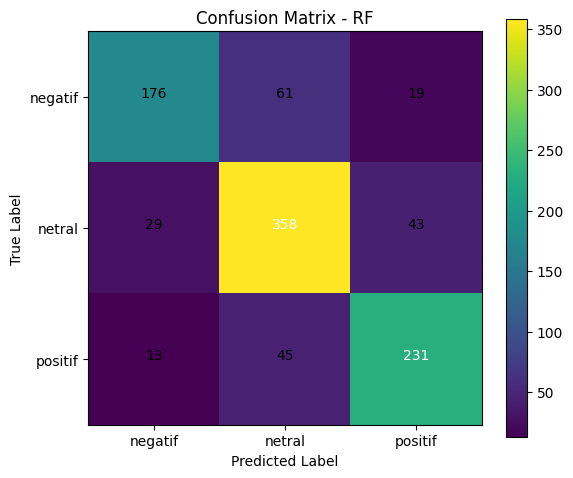

In [ ]:
rf_pred = rf_final.predict(X_test_final)

rf_metrics = compute_metrics_full(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("RF Metrics:", rf_metrics)
print(classification_report(y_test, rf_pred, target_names=label_names, zero_division=0))
plot_confusion_matrix_simple(rf_cm, label_names, "Confusion Matrix - RF")

In [ ]:
joblib.dump(svm_final, f'{MODEL_DIR}/svm_model.pkl')
joblib.dump(rf_final, f'{MODEL_DIR}/rf_model.pkl')
joblib.dump(tfidf_final, f'{MODEL_DIR}/tfidf_vectorizer.pkl')

summary_df = pd.DataFrame([
    {
        'model': 'SVM',
        'best_params': str({'C': best_svm_c}),
        'accuracy': svm_metrics['accuracy'],
        'precision_macro': svm_metrics['precision_macro'],
        'recall_macro': svm_metrics['recall_macro'],
        'f1_macro': svm_metrics['f1_macro']
    },
    {
        'model': 'RandomForest',
        'best_params': str(best_rf_params),
        'accuracy': rf_metrics['accuracy'],
        'precision_macro': rf_metrics['precision_macro'],
        'recall_macro': rf_metrics['recall_macro'],
        'f1_macro': rf_metrics['f1_macro']
    }
])

summary_df.to_csv(f'{ARTIFACT_DIR}/classical_metrics_summary.csv', index=False)
summary_df

,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
0,SVM,{'C': 0.5},0.829744,0.830816,0.827130,0.828889
1,RandomForest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.784615,0.789096,0.773122,0.779108
